# Engine fault analysis

I use this notebook to check the data and try three models with scikit-learn.
Everything runs locally on CPU. Run the cells from top to bottom.

This uses the same settings and test data as the first run, so it is not a new test.

In [1]:
from pathlib import Path
import hashlib
import json
import warnings
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from threadpoolctl import threadpool_limits

%matplotlib inline
ROOT = Path.cwd()
DATA = ROOT / 'EngineFaultDB_Final.csv'
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
SEED = 42
CLASSES = [0, 1, 2, 3]
FEATURES = ['MAP', 'TPS', 'Force', 'Power', 'RPM', 'Consumption L/H',
            'Consumption L/100KM', 'Speed', 'CO', 'HC', 'CO2', 'O2', 'Lambda', 'AFR']
COLORS = ['#2878B5', '#E59626', '#279A81', '#AE5EAA']
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', None)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})
raw = pd.read_csv(DATA)
data_hash = hashlib.sha256(DATA.read_bytes()).hexdigest()
print(f'{len(raw):,} rows; {len(FEATURES)} features')
print('Dataset SHA-256:', data_hash)

55,999 rows; 14 features
Dataset SHA-256: 70021a35b2b2efb294e49f4c78b80a391a05414d44d4564c429645eb32260763


## Check the data

Each row has 14 measurements and a `Fault` label. Class `0` means no fault.
I still need to check what classes `1`, `2`, and `3` mean. The numbers do not show how serious a fault is.

There are no timestamps or IDs for the vehicle or recording session.
I also need to check the MAP and TPS units before comparing them with OBD-II data.

[Dataset](https://github.com/leoxthomas/EngineFaultDB) · [Paper](https://doi.org/10.1109/ACCESS.2023.3331316)

In [2]:
# Check missing values and remove exact duplicates.
assert raw.columns.tolist() == ['Fault'] + FEATURES
assert all(pd.api.types.is_numeric_dtype(raw[c]) for c in raw.columns)
quality = pd.DataFrame({'type': raw.dtypes.astype(str), 'missing': raw.isna().sum(),
                        'non_finite': (~np.isfinite(raw)).sum()})
display(quality)
print('Extra duplicate rows:', raw.duplicated().sum())
clean = raw.drop_duplicates(keep='first').copy()
assert np.isfinite(clean.to_numpy()).all(), 'Review missing or infinite values.'
assert set(clean.Fault.unique()) == set(CLASSES)
assert not clean.duplicated(FEATURES).any(), 'Identical inputs have conflicting labels.'
print('Rows after removing exact duplicates:', len(clean))

,type,missing,non_finite
Fault,int64,0,0
MAP,float64,0,0
TPS,float64,0,0
Force,float64,0,0
Power,float64,0,0
RPM,float64,0,0
Consumption L/H,float64,0,0
Consumption L/100KM,float64,0,0
Speed,float64,0,0
CO,float64,0,0


Extra duplicate rows: 1
Rows after removing exact duplicates: 55998


### Count the classes

I check how many rows belong to each class. Always guessing the largest class gives a simple starting score.

The rows are sorted by class. I need to mix them when splitting the data. Row order is not time.

,rows,percent
Fault,,
0,16000,28.571939
1,10998,19.639636
2,15000,26.786193
3,14001,25.002232


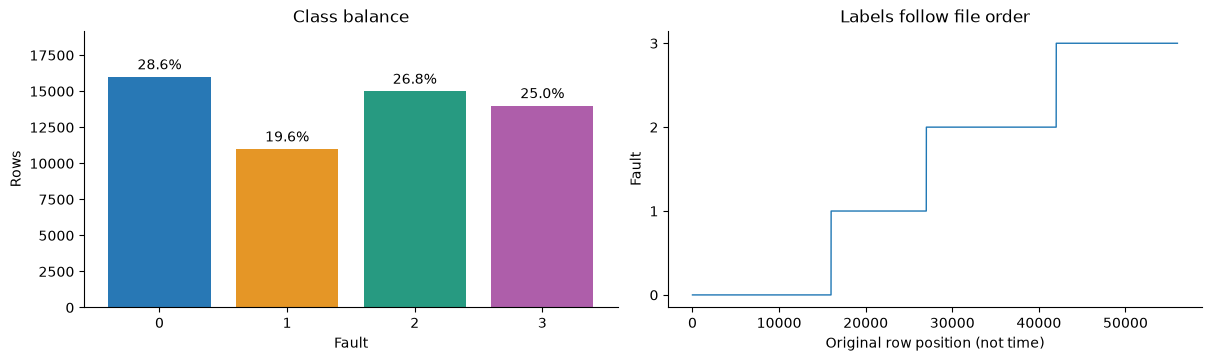

In [3]:
# Count each class and check the row order.
counts = raw.Fault.value_counts().sort_index()
display(pd.DataFrame({'rows': counts, 'percent': counts / len(raw) * 100}))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), layout='constrained')
bars = axes[0].bar(counts.index.astype(str), counts, color=COLORS)
axes[0].bar_label(bars, labels=[f'{v/len(raw):.1%}' for v in counts], padding=3)
axes[0].set(title='Class balance', xlabel='Fault', ylabel='Rows', ylim=(0, counts.max()*1.2))
axes[1].plot(raw.index, raw.Fault, linewidth=1)
axes[1].set(title='Labels follow file order', xlabel='Original row position (not time)', ylabel='Fault', yticks=CLASSES)
plt.show()

## Split the data

I use 70% for training, 15% for validation, and 15% for testing, with similar class proportions.
The saved split keeps the same rows each time and leaves out the duplicate.

From here, I explore only the training data. The earlier review already looked at ranges across the full dataset.

In [4]:
# Reuse the saved split if it exists.
split_path = OUTPUTS / 'split.json'
if split_path.exists():
    split_info = json.loads(split_path.read_text())
    assert split_info['dataset_sha256'] == data_hash, 'The dataset differs from the saved split.'
    assert split_info['seed'] == SEED
    indices = split_info['indices']
else:
    train_part, reserved = train_test_split(clean, test_size=.30, stratify=clean.Fault, random_state=SEED)
    val_part, test_part = train_test_split(reserved, test_size=.50, stratify=reserved.Fault, random_state=SEED)
    indices = {'train': sorted(train_part.index.tolist()),
               'validation': sorted(val_part.index.tolist()), 'test': sorted(test_part.index.tolist())}
    split_info = {'dataset_sha256': data_hash, 'seed': SEED, 'indices': indices}
    split_path.write_text(json.dumps(split_info, indent=2) + '\n')
assert set(indices) == {'train', 'validation', 'test'}
all_ids = [i for rows in indices.values() for i in rows]
assert all(type(i) is int for i in all_ids)
assert len(all_ids) == len(set(all_ids)) and set(all_ids) == set(clean.index)
train = clean.loc[indices['train']].copy()
validation = clean.loc[indices['validation']].copy()
test = clean.loc[indices['test']].copy()
assert all(set(frame.Fault.unique()) == set(CLASSES) for frame in [train, validation, test])
X_train, y_train = train[FEATURES], train.Fault
X_val, y_val = validation[FEATURES], validation.Fault
X_test, y_test = test[FEATURES], test.Fault
X, y = X_train, y_train  # Use shorter names for the plots.
display(pd.DataFrame({'train': train.Fault.value_counts(),
                      'validation': validation.Fault.value_counts(),
                      'test': test.Fault.value_counts()}).sort_index())

,train,validation,test
Fault,,,
0,11200,2400,2400
1,7698,1650,1650
2,10500,2250,2250
3,9800,2100,2100


## Look at the values

I check the ranges, distributions, and unusual values.
The IQR rule flags values far from the middle 50% of the data. I keep these rows because an unusual value is not always an error.

,count,mean,std,min,1%,25%,50%,75%,99%,max
MAP,39198.0,1.836946,0.840206,0.453,0.99300,1.21700,1.5430,1.95000,3.63100,4.547
TPS,39198.0,1.399213,0.910840,0.382,0.75900,0.90100,1.0130,1.25800,3.99800,4.048
Force,39198.0,288.316457,380.344986,2.580,2.71700,76.83825,92.5745,258.90675,1442.19345,1519.908
Power,39198.0,5.683665,7.695696,0.468,0.49200,0.99500,2.4080,5.05875,32.38906,33.879
RPM,39198.0,2395.197616,929.538245,1074.087,1134.70828,1830.34500,2106.3940,2756.29100,4711.98337,4965.090
Consumption L/H,39198.0,4.503397,2.232739,1.917,2.05400,2.98400,3.8240,5.13800,13.81203,14.810
Consumption L/100KM,39198.0,8.957122,3.167425,5.187,5.45600,6.57800,8.0690,9.93900,18.95706,20.043
Speed,39198.0,51.627744,20.078978,22.757,24.54900,39.41800,45.3985,59.44775,101.69703,107.539
CO,39198.0,1.938390,1.995144,0.424,0.44200,0.64100,1.1300,2.45800,9.54500,10.094
HC,39198.0,188.808100,111.796535,1.791,1.91300,158.87525,178.3580,203.86775,917.02758,975.657


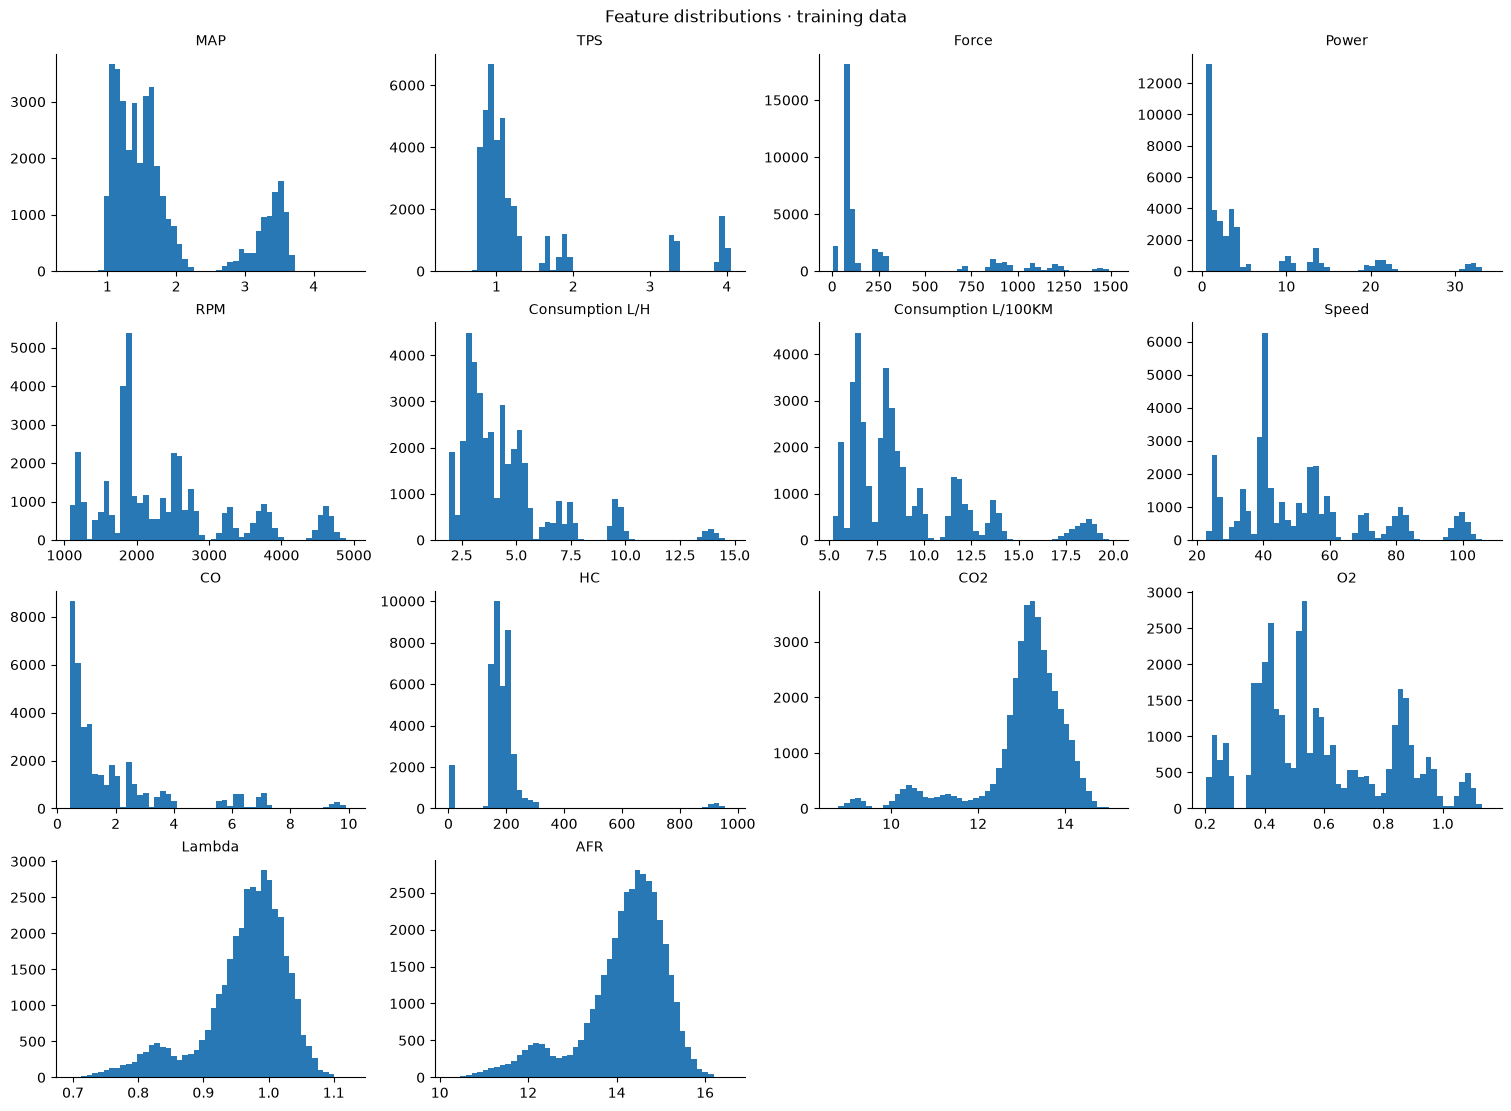

,percent outside IQR rule
Force,19.784173
MAP,18.768815
TPS,18.034083
Power,17.944793
CO,10.819430
CO2,10.773509
HC,9.036175
Consumption L/H,7.283535
RPM,7.076892
Speed,7.076892


In [5]:
# Look at the training values.
display(X.describe(percentiles=[.01, .25, .5, .75, .99]).T)
fig, axes = plt.subplots(4, 4, figsize=(15, 11), layout='constrained')
for ax, feature in zip(axes.flat, FEATURES):
    ax.hist(X[feature], bins=50, color=COLORS[0])
    ax.set_title(feature, fontsize=10)
for ax in axes.flat[len(FEATURES):]:
    ax.set_visible(False)
fig.suptitle('Feature distributions · training data')
plt.show()
q1, q3 = X.quantile(.25), X.quantile(.75)
iqr = q3 - q1
extreme = X.lt(q1 - 1.5*iqr) | X.gt(q3 + 1.5*iqr)
display((extreme.mean()*100).sort_values(ascending=False).rename('percent outside IQR rule').to_frame())

### Compare the features

I use correlation to see which features move together. I leave out `Fault` because it is a class label.
Correlation does not explain what causes a change. The boxplots show how values differ between classes.

,feature_a,feature_b,r
90,Lambda,AFR,0.999990
48,RPM,Speed,0.996878
80,CO,AFR,-0.899446
79,CO,Lambda,-0.899434
13,TPS,Force,0.891945
0,MAP,TPS,0.884802
1,MAP,Force,0.879378
77,CO,CO2,-0.869012
87,CO2,AFR,0.853253
86,CO2,Lambda,0.853253


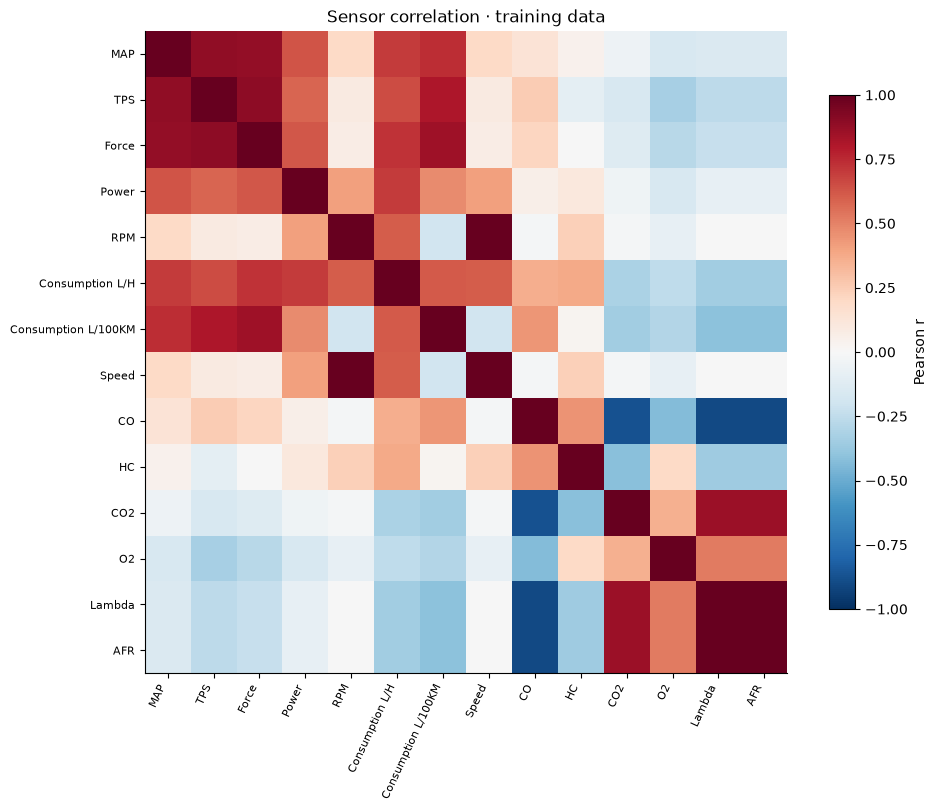

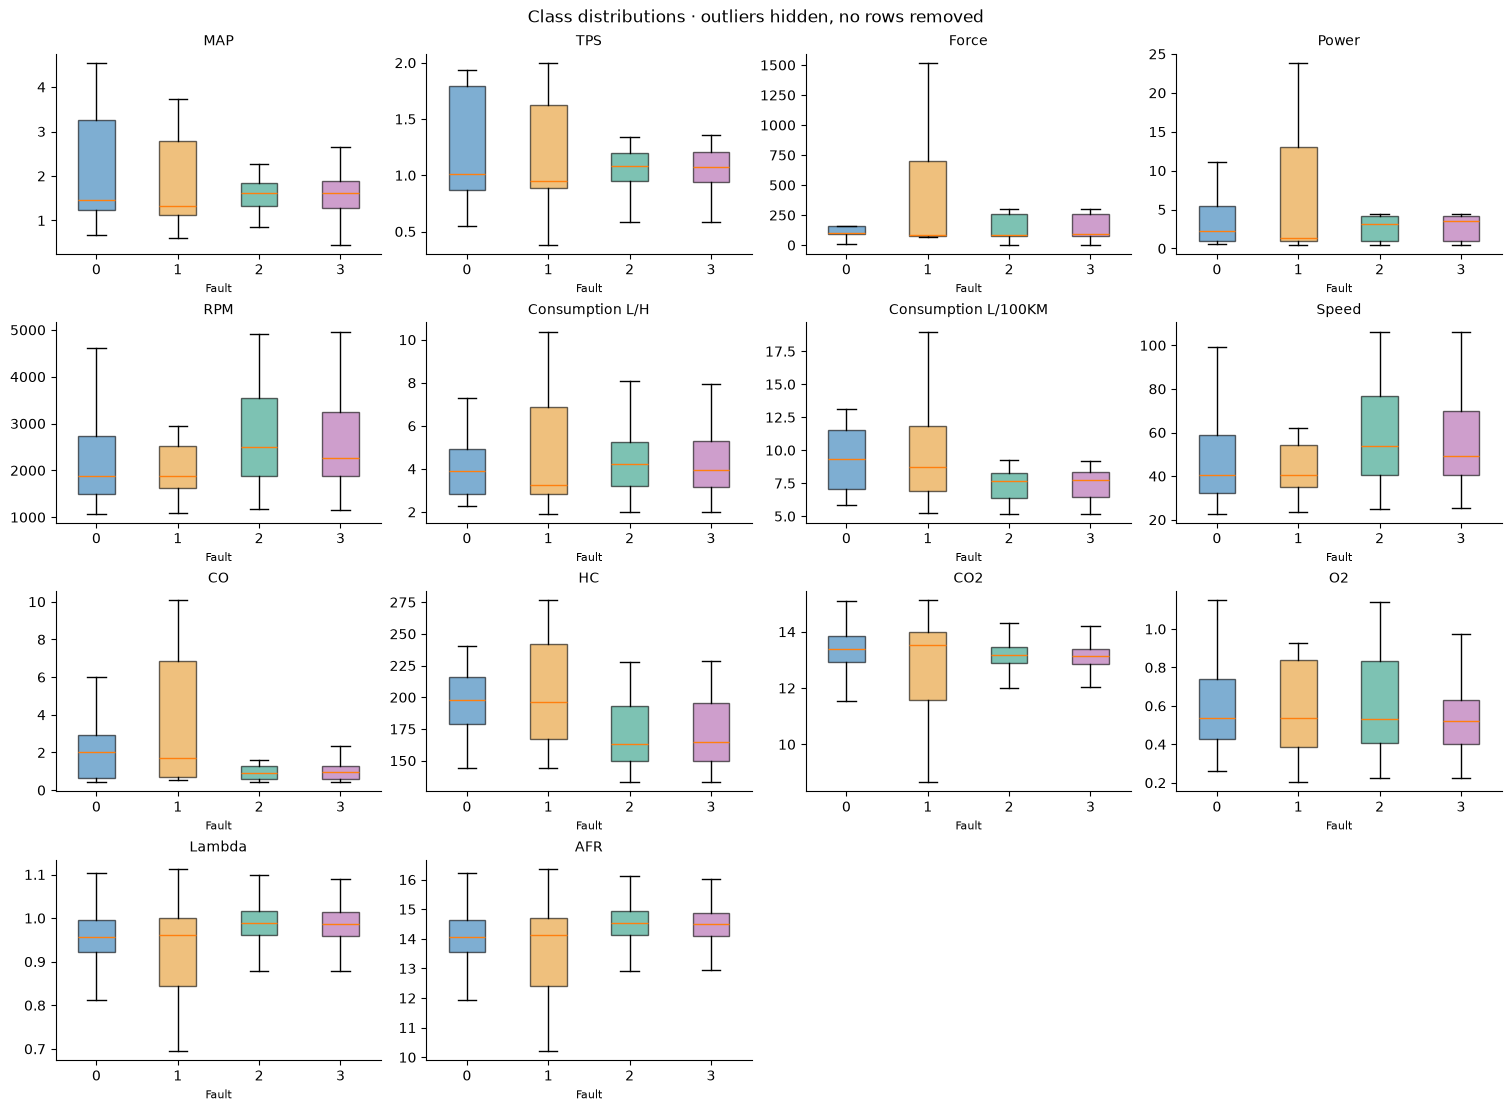

In [6]:
# Compare features and classes.
correlation = X.corr()
pairs = pd.DataFrame([{'feature_a': a, 'feature_b': b, 'r': correlation.loc[a,b]}
                      for i,a in enumerate(FEATURES) for b in FEATURES[i+1:]])
pairs['abs_r'] = pairs.r.abs()
display(pairs.sort_values('abs_r', ascending=False).head(10).drop(columns='abs_r'))
fig, ax = plt.subplots(figsize=(10, 8), layout='constrained')
im = ax.imshow(correlation, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(14), FEATURES, rotation=65, ha='right', fontsize=8)
ax.set_yticks(range(14), FEATURES, fontsize=8)
ax.set_title('Sensor correlation · training data')
fig.colorbar(im, ax=ax, label='Pearson r', shrink=.8)
plt.show()
fig, axes = plt.subplots(4, 4, figsize=(15, 11), layout='constrained')
for ax, feature in zip(axes.flat, FEATURES):
    boxes = ax.boxplot([train.loc[y.eq(label), feature] for label in CLASSES],
                       tick_labels=[str(label) for label in CLASSES], showfliers=False, patch_artist=True)
    for box, color in zip(boxes['boxes'], COLORS):
        box.set_facecolor(color)
        box.set_alpha(.6)
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel('Fault', fontsize=8)
for ax in axes.flat[len(FEATURES):]:
    ax.set_visible(False)
fig.suptitle('Class distributions · outliers hidden, no rows removed')
plt.show()

### Compare nearby rows

I compare nearby training rows with shuffled rows from the same class.
A ratio below 1 means nearby rows are more similar. This checks the file order, not time.

In [7]:
# Check whether nearby rows are more similar.
ratios = []
for label in CLASSES:
    ordered = train.loc[y.eq(label), FEATURES].sort_index()
    shuffled = ordered.sample(frac=1, random_state=SEED)
    ratio = ordered.diff().abs().median() / shuffled.diff().abs().median().replace(0, np.nan)
    ratios.append(ratio.rename(label))
neighbor_ratios = pd.concat(ratios, axis=1)
display(neighbor_ratios.round(3))
print('Median neighbor/shuffled change ratio:', round(float(np.nanmedian(neighbor_ratios)), 4))

,0,1,2,3
MAP,0.093,0.106,0.100,0.094
TPS,0.025,0.132,0.057,0.054
Force,0.040,0.015,0.014,0.013
Power,0.020,0.019,0.017,0.017
RPM,0.049,0.060,0.060,0.062
Consumption L/H,0.054,0.042,0.054,0.051
Consumption L/100KM,0.074,0.057,0.096,0.100
Speed,0.049,0.062,0.060,0.061
CO,0.022,0.011,0.037,0.035
HC,0.126,0.094,0.112,0.104


Median neighbor/shuffled change ratio: 0.0597


Lambda/AFR and RPM/Speed are very similar. Classes 2 and 3 also look similar.
Nearby rows are close to each other, which could make a random split look better than it would on new data.

## Try the models

All three models use scikit-learn. `.fit()` trains the model and `.predict()` makes predictions.
I compare them on validation data and leave test for the selected model.

### Dummy

`DummyClassifier` always picks the most common training class.
I use it as a basic score to beat.

In [8]:
# Train the simple reference model.
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_predictions = dummy.predict(X_val)
print('Dummy validation macro F1:', f1_score(y_val, dummy_predictions, average='macro', zero_division=0))

Dummy validation macro F1: 0.1111111111111111


### Random Forest

`RandomForestClassifier` combines 200 decision trees.
I keep the same settings as the first run and use two CPU workers.

In [9]:
# Train the Random Forest.
forest = RandomForestClassifier(n_estimators=200, min_samples_leaf=2, random_state=SEED, n_jobs=2)
forest.fit(X_train, y_train)
forest_predictions = forest.predict(X_val)
print('Random Forest validation macro F1:', f1_score(y_val, forest_predictions, average='macro', zero_division=0))

Random Forest validation macro F1: 0.7522288079032691


### Neural network

`MLPClassifier` has two hidden layers with 64 and 32 neurons.
I use `StandardScaler` to put the inputs on similar scales. It learns the scaling from training data only.

The model trains for up to 100 epochs. It can stop sooner if training loss stops improving.
It does not create another validation split.

MLP validation macro F1: 0.7285899154226556
Training warnings: none


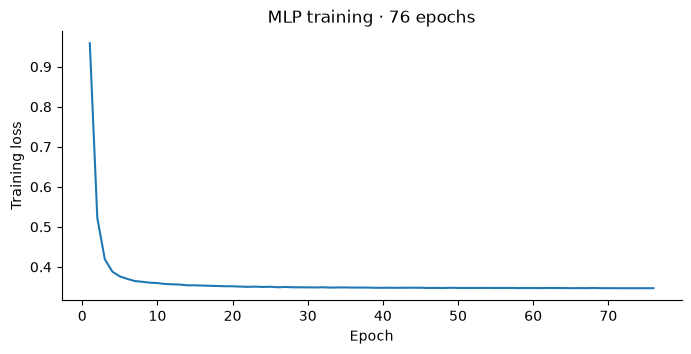

In [10]:
# Scale the inputs and train the neural network.
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                  batch_size=256, max_iter=100, early_stopping=False, random_state=SEED),
)
with threadpool_limits(limits=2), warnings.catch_warnings(record=True) as training_warnings:
    warnings.simplefilter('always')
    mlp.fit(X_train, y_train)
mlp_predictions = mlp.predict(X_val)
print('MLP validation macro F1:', f1_score(y_val, mlp_predictions, average='macro', zero_division=0))
print('Training warnings:', [str(w.message) for w in training_warnings] or 'none')
network = mlp.named_steps['mlpclassifier']
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, len(network.loss_curve_)+1), network.loss_curve_)
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title(f'MLP training · {network.n_iter_} epochs')
plt.show()

## Compare the results

I choose the model with the best validation macro F1, which gives each class equal weight.
I also check accuracy and balanced accuracy. Balanced accuracy averages recall across classes.

,macro_f1,accuracy,balanced_accuracy
random_forest,0.752229,0.743810,0.752238
mlp,0.728590,0.742857,0.757063
dummy,0.111111,0.285714,0.250000


Selected: random_forest


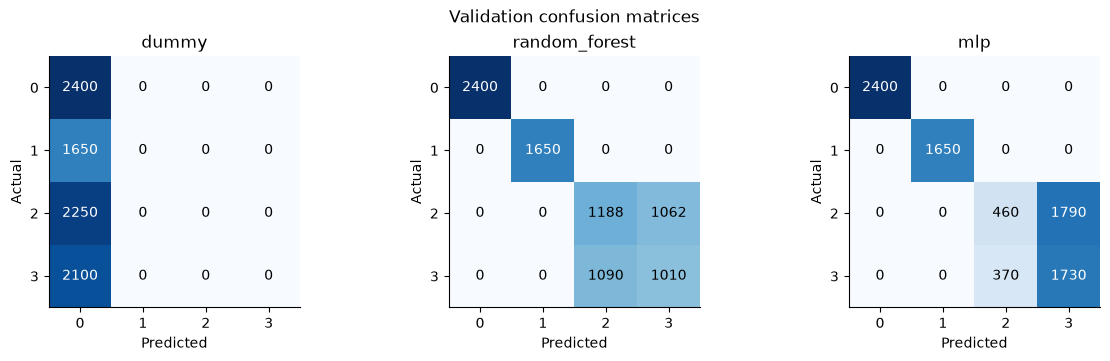

In [11]:
# Pick the best model using validation.
models = {'dummy': dummy, 'random_forest': forest, 'mlp': mlp}
validation_predictions = {'dummy': dummy_predictions, 'random_forest': forest_predictions, 'mlp': mlp_predictions}
comparison = pd.DataFrame({name: {
    'macro_f1': f1_score(y_val, pred, average='macro', zero_division=0),
    'accuracy': accuracy_score(y_val, pred),
    'balanced_accuracy': balanced_accuracy_score(y_val, pred),
} for name, pred in validation_predictions.items()}).T
winner = comparison.macro_f1.idxmax()
best_model = models[winner]
display(comparison.sort_values('macro_f1', ascending=False))
print('Selected:', winner)
selection = {'model': winner, 'validation_macro_f1': float(comparison.loc[winner, 'macro_f1'])}
(OUTPUTS / 'selection.json').write_text(json.dumps(selection, indent=2) + '\n')
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout='constrained')
for ax, (name, pred) in zip(axes, validation_predictions.items()):
    matrix = confusion_matrix(y_val, pred, labels=CLASSES)
    ax.imshow(matrix, cmap='Blues')
    for (i,j), value in np.ndenumerate(matrix):
        ax.text(j, i, str(value), ha='center', va='center', color='white' if value > matrix.max()*.5 else 'black')
    ax.set(title=name, xlabel='Predicted', ylabel='Actual', xticks=CLASSES, yticks=CLASSES)
fig.suptitle('Validation confusion matrices')
plt.show()

## Check the selected model on test

The model has already been chosen using validation. I now check it on test without changing its settings.
This is the same test data used before, so running it again does not count as a new evaluation.

,random_forest
macro_f1,0.762348
accuracy,0.754048
balanced_accuracy,0.762365


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,2400.0
1,1.000000,1.000000,1.000000,1650.0
2,0.541441,0.534222,0.537808,2250.0
3,0.507981,0.515238,0.511584,2100.0


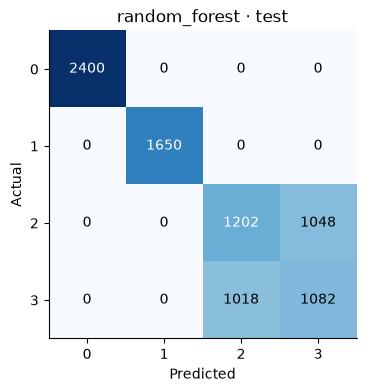

Errors between classes 2 and 3: 2066


In [12]:
# Test the selected model.
test_predictions = best_model.predict(X_test)
test_metrics = {
    'macro_f1': f1_score(y_test, test_predictions, average='macro', zero_division=0),
    'accuracy': accuracy_score(y_test, test_predictions),
    'balanced_accuracy': balanced_accuracy_score(y_test, test_predictions),
}
display(pd.Series(test_metrics, name=winner).to_frame())
class_report = classification_report(y_test, test_predictions, labels=CLASSES, output_dict=True, zero_division=0)
display(pd.DataFrame({label: class_report[str(label)] for label in CLASSES}).T)
matrix = confusion_matrix(y_test, test_predictions, labels=CLASSES)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(matrix, cmap='Blues')
for (i,j), value in np.ndenumerate(matrix):
    ax.text(j, i, str(value), ha='center', va='center', color='white' if value > matrix.max()*.5 else 'black')
ax.set(title=f'{winner} · test', xlabel='Predicted', ylabel='Actual', xticks=CLASSES, yticks=CLASSES)
plt.show()
print('Errors between classes 2 and 3:', matrix[2,3] + matrix[3,2])

## Save and try the model

I save the model with `joblib`, load it again, and check that the predictions match.
Only load model files you trust.

For the example, I take the first two test rows from each class. The model gets the 14 features, without `Fault`.
The real labels are only shown to compare results. Running this again replaces the files in `outputs/`.

In [13]:
# Save the model and try it on a few rows.
model_path = OUTPUTS / 'model.joblib'
joblib.dump(best_model, model_path, compress=3)
loaded_model = joblib.load(model_path)
demo_ids = test.groupby('Fault', sort=True).head(2).index
new_inputs = test.loc[demo_ids, FEATURES]
new_predictions = loaded_model.predict(new_inputs)
cached_predictions = pd.Series(test_predictions, index=test.index)
np.testing.assert_array_equal(new_predictions, cached_predictions.loc[demo_ids].to_numpy())
display(pd.DataFrame({'actual': test.loc[demo_ids, 'Fault'], 'predicted': new_predictions}))
results = {
    'dataset_sha256': data_hash, 'seed': SEED, 'features': FEATURES, 'labels': CLASSES,
    'split_sizes': {name: len(rows) for name, rows in indices.items()},
    'validation': comparison.to_dict(orient='index'), 'selected_model': winner,
    'test': test_metrics, 'per_class': class_report, 'confusion_matrix': matrix.tolist(),
    'mlp_epochs': int(network.n_iter_), 'mlp_warnings': [str(w.message) for w in training_warnings],
    'versions': {name: version(name) for name in ['numpy', 'pandas', 'scikit-learn', 'joblib']},
    'note': 'Fixed baseline replay; test previously consulted; no new-vehicle validation.',
}
(OUTPUTS / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False) + '\n')
assert hashlib.sha256(DATA.read_bytes()).hexdigest() == data_hash
print('Saved model and results in outputs/. Original CSV unchanged. Reload verified.')

,actual,predicted
1,0,0
4,0,0
16005,1,1
16012,1,1
27008,2,2
27010,2,2
41999,3,2
42000,3,2


Saved model and results in outputs/. Original CSV unchanged. Reload verified.


## Notes

Random Forest did best in the first run: about 0.752 validation macro F1 and 0.762 test macro F1.
Classes 2 and 3 are the hardest to tell apart.

Nearby rows are very similar, so these scores may look better than results on new data.
This does not show that the model can predict future failures or work on another vehicle.
I still need to check the fault labels, sensor units, and recording sessions.

Next, I want to look closer at classes 2 and 3 using training and validation data, then try fewer features.
I should not use test results to tune the models.